<a href="https://colab.research.google.com/github/Aditya-Kumar-Sharma/MovieSuccessPrediction/blob/main/3_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Bollywood Box Office Predictor
## Notebook 3: Sentiment Analysis

**Goal:**
- Load raw comments from Notebook 1
- Clean and preprocess text
- Run 3-stage sentiment pipeline:
  1. VADER (rule-based, fast)
  2. TextBlob (linguistic, interpretable)
  3. HuggingFace Transformer RoBERTa (deep learning, most accurate)
- Build Theatre Excitement Score
- Build OTT Preference Score
- Build Controversy Intensity Score
- 3-Layer Sarcasm Detection (Emoji + Pattern + Transformer)
- Sarcasm-adjusted sentiment scoring
- Aggregate all scores per movie
- Save sentiment features

### Pipeline Flow
```
46,000+ raw comments
        ↓
   Text Cleaning
        ↓
   VADER → TextBlob → RoBERTa
        ↓
   Sarcasm Detection (3 approaches)
        ↓
   Sarcasm-Adjusted Sentiment
        ↓
   Keyword Scoring (Theatre / OTT / Controversy / Hype)
        ↓
   Aggregate per movie → Save
```

In [1]:
# ── CELL 2: INSTALL LIBRARIES ─────────────────────────────────────────────
!pip install vaderSentiment textblob transformers torch wordcloud -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print('✅ Libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00
✅ Libraries installed


In [2]:
# ── CELL 3: IMPORTS ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Sentiment libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline

# NLP
from nltk.corpus import stopwords
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
STOP_WORDS = set(stopwords.words('english'))
print('✅ All imports successful')

✅ All imports successful


In [3]:
# ── CELL 4: MOUNT DRIVE & LOAD DATA ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH   = '/content/drive/MyDrive/Bollywood_Predictor/'
comments_df = pd.read_csv(f'{SAVE_PATH}comments_raw.csv')
movies_df   = pd.read_csv(f'{SAVE_PATH}movies_enriched.csv')

print(f'✅ Comments loaded  : {comments_df.shape}')
print(f'✅ Movies loaded    : {movies_df.shape}')
print(f'\n📊 Comments by source type:')
print(comments_df['source'].value_counts())
print(f'\n📊 Comments by movie and source:')
print(comments_df.groupby(['movie','source'])['text'].count().unstack().fillna(0).astype(int))

Mounted at /content/drive
✅ Comments loaded  : (46696, 7)
✅ Movies loaded    : (12, 66)

📊 Comments by source type:
source
trailer    24000
music_1    12000
music_2    10696
Name: count, dtype: int64

📊 Comments by movie and source:
source                         music_1  music_2  trailer
movie                                                   
Adipurush                         1000     1000     2000
Animal                             999     1000     2000
Bholaa                            1000      696     2000
Jawan                             1000     1000     2000
KGF Chapter 2                     1000     1000     2000
OMG 2                             1000     1000     2000
Pathaan                           1000     1000     2000
Pushpa 2                          1000     1000     2000
Rocky Aur Rani Ki Prem Kahani     1000     1000     2000
Selfiee                           1000     1000     2000
The Kashmir Files                 1000        0     2000
Tu Jhoothi Main Makkaar   

In [4]:
# ── CELL 5: TEXT CLEANING ─────────────────────────────────────────────────

def clean_text(text):
    """
    Full cleaning pipeline for keyword scoring:
    Lowercase, remove URLs, special chars, extra spaces
    NOTE: does NOT remove emojis — emojis preserved in original text
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # removes emojis
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_for_sentiment(text):
    """
    Lighter cleaning for sentiment models:
    Keeps punctuation and capitalization for better model accuracy
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
# IMPORTANT: Keep original 'text' column untouched — needed for emoji sarcasm detection
comments_df['text_clean']     = comments_df['text'].apply(clean_text)
comments_df['text_sentiment'] = comments_df['text'].apply(clean_text_for_sentiment)

# Remove empty comments
comments_df = comments_df[comments_df['text_clean'].str.len() > 3].reset_index(drop=True)

print(f'✅ Text cleaning complete')
print(f'   Comments after cleaning: {len(comments_df):,}')
print(f'\n📝 Sample cleaned comments:')
for i in range(3):
    print(f'   Original : {str(comments_df["text"].iloc[i])[:80]}')
    print(f'   Cleaned  : {comments_df["text_clean"].iloc[i][:80]}')
    print()

✅ Text cleaning complete
   Comments after cleaning: 39,353

📝 Sample cleaned comments:
   Original : Ab kuch log aayenge aur bolenge who come after toxic teaser 😂
   Cleaned  : ab kuch log aayenge aur bolenge who come after toxic teaser

   Original : Is there anyone who is here to watch the trailer after movie ? 🔥🔥
   Cleaned  : is there anyone who is here to watch the trailer after movie

   Original : Who here after Toxic: Raya introduction ☠️☠️
   Cleaned  : who here after toxic raya introduction



In [5]:
# ── CELL 6: VADER SENTIMENT ───────────────────────────────────────────────
# Stage 1: Rule-based sentiment
# Fast, works well for social media text
# Limitation: misses context, sarcasm, Hindi/Hinglish text

print('⚙️  Running VADER sentiment analysis...')

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores   = vader.polarity_scores(str(text))
    compound = scores['compound']
    if compound >=  0.05: label = 'positive'
    elif compound <= -0.05: label = 'negative'
    else: label = 'neutral'
    return pd.Series({
        'vader_compound' : compound,
        'vader_positive' : scores['pos'],
        'vader_negative' : scores['neg'],
        'vader_neutral'  : scores['neu'],
        'vader_label'    : label
    })

vader_results = comments_df['text_sentiment'].apply(get_vader_sentiment)
comments_df   = pd.concat([comments_df, vader_results], axis=1)

print(f'✅ VADER complete')
print(f'\n📊 VADER Sentiment Distribution:')
print(comments_df['vader_label'].value_counts())
print(f'\n📊 VADER avg compound score by movie:')
print(comments_df.groupby('movie')['vader_compound'].mean().sort_values(ascending=False).round(3))

⚙️  Running VADER sentiment analysis...
✅ VADER complete

📊 VADER Sentiment Distribution:
vader_label
neutral     22269
positive    13079
negative     4005
Name: count, dtype: int64

📊 VADER avg compound score by movie:
movie
Rocky Aur Rani Ki Prem Kahani    0.200
Tu Jhoothi Main Makkaar          0.180
Bholaa                           0.165
Selfiee                          0.163
OMG 2                            0.153
Jawan                            0.152
KGF Chapter 2                    0.148
Pathaan                          0.118
Animal                           0.118
The Kashmir Files                0.083
Adipurush                        0.077
Pushpa 2                         0.036
Name: vader_compound, dtype: float64


In [6]:
# ── CELL 7: TEXTBLOB SENTIMENT ────────────────────────────────────────────
# Stage 2: Linguistic approach
# Returns polarity (-1 to +1) AND subjectivity (0=fact, 1=opinion)
# Limitation: English only, misses Hinglish

print('⚙️  Running TextBlob sentiment analysis...')

def get_textblob_sentiment(text):
    analysis     = TextBlob(str(text))
    polarity     = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity
    if polarity   >  0.1: label = 'positive'
    elif polarity < -0.1: label = 'negative'
    else: label = 'neutral'
    return pd.Series({
        'tb_polarity'    : round(polarity,     4),
        'tb_subjectivity': round(subjectivity, 4),
        'tb_label'       : label
    })

tb_results  = comments_df['text_sentiment'].apply(get_textblob_sentiment)
comments_df = pd.concat([comments_df, tb_results], axis=1)

print(f'✅ TextBlob complete')
print(f'\n📊 TextBlob Sentiment Distribution:')
print(comments_df['tb_label'].value_counts())
print(f'\n📊 Average Subjectivity by Movie (higher = more opinionated):')
print(comments_df.groupby('movie')['tb_subjectivity'].mean().sort_values(ascending=False).round(3))

⚙️  Running TextBlob sentiment analysis...
✅ TextBlob complete

📊 TextBlob Sentiment Distribution:
tb_label
neutral     27053
positive    10630
negative     1670
Name: count, dtype: int64

📊 Average Subjectivity by Movie (higher = more opinionated):
movie
Rocky Aur Rani Ki Prem Kahani    0.289
The Kashmir Files                0.271
Tu Jhoothi Main Makkaar          0.264
Selfiee                          0.254
Bholaa                           0.237
KGF Chapter 2                    0.234
Animal                           0.228
Pathaan                          0.218
OMG 2                            0.213
Jawan                            0.190
Pushpa 2                         0.154
Adipurush                        0.143
Name: tb_subjectivity, dtype: float64


In [7]:
# ── CELL 8: HUGGINGFACE TRANSFORMER ──────────────────────────────────────
# Stage 3: Deep learning — most accurate
# Model: cardiffnlp/twitter-roberta-base-sentiment
# Trained on 58M tweets — perfect for YouTube comments
# Labels: LABEL_0=negative, LABEL_1=neutral, LABEL_2=positive

print('⚙️  Loading HuggingFace RoBERTa sentiment model...')
print('   Model: cardiffnlp/twitter-roberta-base-sentiment')

sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model      = 'cardiffnlp/twitter-roberta-base-sentiment',
    max_length = 512,
    truncation = True
)

# IMPORTANT FIX: Correct score mapping
# positive → +score (0 to +1)
# neutral  →  0     (not negative!)
# negative → -score (-1 to 0)

def get_transformer_sentiment(text):
    try:
        result    = sentiment_pipeline(str(text)[:512])[0]
        label     = result['label'].lower()
        score     = result['score']  # confidence (0 to 1)
        label_map = {
            'label_0': 'negative',
            'label_1': 'neutral',
            'label_2': 'positive'
        }
        mapped_label = label_map.get(label, label)

        # CORRECTED scoring — neutral stays near 0, not negative
        if mapped_label == 'positive': sentiment_score = +score
        elif mapped_label == 'negative': sentiment_score = -score
        else: sentiment_score = 0.0  # neutral = 0, not -score

        return pd.Series({
            'transformer_label': mapped_label,
            'transformer_score': round(sentiment_score, 4)
        })
    except:
        return pd.Series({
            'transformer_label': 'neutral',
            'transformer_score': 0.0
        })

print('⚙️  Running transformer on all comments (5-10 mins)...')
transformer_results = comments_df['text_sentiment'].apply(get_transformer_sentiment)
comments_df         = pd.concat([comments_df, transformer_results], axis=1)

print(f'✅ Transformer complete')
print(f'\n📊 Transformer Sentiment Distribution:')
print(comments_df['transformer_label'].value_counts())
print(f'\n📊 Transformer avg score by movie:')
print(comments_df.groupby('movie')['transformer_score'].mean().sort_values(ascending=False).round(3))

⚙️  Loading HuggingFace RoBERTa sentiment model...
   Model: cardiffnlp/twitter-roberta-base-sentiment


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

⚙️  Running transformer on all comments (5-10 mins)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Transformer complete

📊 Transformer Sentiment Distribution:
transformer_label
neutral     27020
positive     9500
negative     2833
Name: count, dtype: int64

📊 Transformer avg score by movie:
movie
Rocky Aur Rani Ki Prem Kahani    0.240
Jawan                            0.215
Tu Jhoothi Main Makkaar          0.213
Bholaa                           0.183
OMG 2                            0.178
Selfiee                          0.168
Animal                           0.146
KGF Chapter 2                    0.131
Pathaan                          0.131
Pushpa 2                         0.097
Adipurush                        0.069
The Kashmir Files               -0.026
Name: transformer_score, dtype: float64


In [8]:
# ── CELL 9: KEYWORD SCORING ───────────────────────────────────────────────
# Custom features that standard sentiment models miss
# Theatre Excitement: will people go to theatres?
# OTT Preference: will people skip theatres?
# Controversy: how polarized is audience?
# Hype: how excited is audience?

THEATRE_KEYWORDS = [
    'fdfs', 'first day first show', 'book ticket', 'book tickets',
    'theatre', 'theater', 'cinema', 'imax', '4dx', 'day one',
    'cannot wait', "can't wait", 'watching in theatre',
    'goosebumps', 'mass', 'interval', 'whistles', 'celebrate',
    'watching on opening', 'first show', 'advance booking'
]
OTT_KEYWORDS = [
    'ott', 'netflix', 'prime', 'amazon', 'hotstar', 'disney',
    'wait for ott', 'watch at home', 'not worth theatre',
    'streaming', 'digital', 'download', 'home release',
    'skip theatre', 'wait for online', 'zee5', 'jiocinema'
]
CONTROVERSY_KEYWORDS = [
    'boycott', 'ban', 'hate', 'pathetic', 'disgusting', 'shameful',
    'propaganda', 'trash', 'worst', 'never watching', 'flop',
    'disaster', 'terrible', 'awful', 'waste', 'fraud'
]
HYPE_KEYWORDS = [
    'blockbuster', 'masterpiece', 'epic', 'legendary', 'brilliant',
    'outstanding', 'incredible', 'amazing', 'perfect', 'superhit',
    'must watch', 'best film', 'all time', 'goat', 'fire'
]

def score_keywords(text, keywords):
    text  = str(text).lower()
    return min(sum(1 for kw in keywords if kw in text), 3)

comments_df['theatre_excitement'] = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, THEATRE_KEYWORDS))
comments_df['ott_preference']     = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, OTT_KEYWORDS))
comments_df['controversy_score']  = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, CONTROVERSY_KEYWORDS))
comments_df['hype_score']         = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, HYPE_KEYWORDS))

print('✅ Keyword scoring complete')
print(f'   Theatre excitement hits : {(comments_df["theatre_excitement"]>0).sum():,}')
print(f'   OTT preference hits     : {(comments_df["ott_preference"]>0).sum():,}')
print(f'   Controversy hits        : {(comments_df["controversy_score"]>0).sum():,}')
print(f'   Hype keyword hits       : {(comments_df["hype_score"]>0).sum():,}')

✅ Keyword scoring complete
   Theatre excitement hits : 1,591
   OTT preference hits     : 318
   Controversy hits        : 1,509
   Hype keyword hits       : 1,916


In [9]:
# ── CELL 10: SARCASM DETECTION APPROACH 1 — EMOJI SIGNALS ────────────────
# Why: Emojis like 💀🤡🙄 signal sarcasm but only WITH negative context
# Key insight: 😂💀 after "goosebumps" = excitement, not sarcasm
#              😂💀 after "worst movie" = sarcasm
# Solution: only flag sarcasm if emoji + negative context word present

SARCASM_EMOJIS = ['😂', '💀', '🤡', '🙄', '😬', '🗿']
GENUINE_EMOJIS = ['🔥', '❤️', '😍', '🙏', '👏', '💯', '🥺', '⭐']

# Negative context words that make emoji sarcastic
NEGATIVE_CONTEXT = [
    'worst', 'terrible', 'awful', 'pathetic', 'disaster',
    'flop', 'waste', 'trash', 'boring', 'cringe', 'bad',
    'disappointing', 'overrated', 'skip', 'avoid'
]

def emoji_sarcasm_score(row):
    """
    Smarter emoji sarcasm detection:
    Only flags sarcasm if BOTH conditions met:
    1. Has sarcasm emoji
    2. Has negative context word OR clearly more sarcasm than genuine emojis
    """
    original      = str(row['text'])
    text_clean    = str(row['text_clean']).lower()

    sarcasm_count = sum(1 for e in SARCASM_EMOJIS if e in original)
    genuine_count = sum(1 for e in GENUINE_EMOJIS if e in original)
    negative_ctx  = sum(1 for w in NEGATIVE_CONTEXT if w in text_clean)

    is_sarcastic  = (
        sarcasm_count > 0 and
        (negative_ctx > 0 or sarcasm_count > genuine_count + 1)
    )

    return pd.Series({
        'emoji_sarcasm_count'   : sarcasm_count,
        'emoji_genuine_count'   : genuine_count,
        'emoji_likely_sarcastic': int(is_sarcastic)
    })

# Apply using ORIGINAL text to preserve emojis
emoji_results = comments_df[['text','text_clean']].apply(emoji_sarcasm_score, axis=1)
comments_df   = pd.concat([comments_df, emoji_results], axis=1)

emoji_count = comments_df['emoji_likely_sarcastic'].sum()
print(f'✅ Emoji sarcasm detection complete')
print(f'   Sarcastic via emojis: {emoji_count:,} comments ({emoji_count/len(comments_df)*100:.1f}%)')

# Show examples
examples = comments_df[comments_df['emoji_likely_sarcastic']==1]['text'].head(3)
print(f'\n📝 Sample emoji sarcasm detections:')
for ex in examples:
    print(f'   → {str(ex)[:80]}')

✅ Emoji sarcasm detection complete
   Sarcastic via emojis: 138 comments (0.4%)

📝 Sample emoji sarcasm detections:
   → Jaise tu support nahi karega to film flop jayegi😂😂🤣🤣
   → Bhaii iss movie ko promotion ki jararatich nhi he ..iska naam hi promotion he..t
   → Kgf Worldwide collection- 250cr = All time blockbuster Yash is the biggest super


In [10]:
# ── CELL 11: SARCASM DETECTION APPROACH 2 — LINGUISTIC PATTERNS ──────────
# Detects sarcasm through sentence structure
# Example: "10/10 lmao", "oscar worthy haha", "clearly the best lol"

SARCASM_PATTERNS = [
    r'\b(totally|absolutely|clearly|obviously)\b.*\b(masterpiece|brilliant|genius|perfect)\b',
    r'wow+\s+such',
    r'oh\s+great',
    r'just\s+what\s+we\s+needed',
    r'10\s*/\s*10\s*(lol|lmao|haha)',
    r'oscar\s+worthy.*(lol|lmao|haha)',
    r'best\s+film.*(lol|lmao|haha)',
    r'(lmao|lmaooo|lol|haha)\s*(masterpiece|brilliant|genius)',
    r'(sure|yeah\s+right|totally)\s+(great|good|amazing|brilliant)',
    r'what\s+a\s+(masterpiece|film|movie|performance).*(lol|lmao|haha)',
]

def pattern_sarcasm_score(text):
    text_lower = str(text).lower()
    return min(sum(1 for p in SARCASM_PATTERNS
                   if re.search(p, text_lower)), 3)

comments_df['pattern_sarcasm'] = comments_df['text_clean'].apply(
    pattern_sarcasm_score)

pattern_count = (comments_df['pattern_sarcasm'] > 0).sum()
print(f'✅ Pattern sarcasm detection complete')
print(f'   Sarcastic via patterns: {pattern_count:,} comments ({pattern_count/len(comments_df)*100:.2f}%)')

examples = comments_df[comments_df['pattern_sarcasm']>0]['text'].head(3)
print(f'\n📝 Sample pattern sarcasm detections:')
for ex in examples:
    print(f'   → {str(ex)[:80]}')

✅ Pattern sarcasm detection complete
   Sarcastic via patterns: 8 comments (0.02%)

📝 Sample pattern sarcasm detections:
   → Absolutely 💯 right 👍🏾 perfect
   → This is totally masterpiece, everyone should watch this movie in theater only an
   → "Wow, the Bholaa trailer looks absolutely incredible! The stunning visuals and p


In [11]:
# ── CELL 12: SARCASM DETECTION APPROACH 3 — HUGGINGFACE TRANSFORMER ──────
# Deep learning sarcasm model
# Model: helinivan/english-sarcasm-detector
# Most sophisticated approach — understands full sentence context

print('⚙️  Loading HuggingFace sarcasm detection model...')
print('   Model: helinivan/english-sarcasm-detector')

try:
    sarcasm_pipeline = pipeline(
        'text-classification',
        model      = 'helinivan/english-sarcasm-detector',
        max_length = 512,
        truncation = True
    )
    SARCASM_MODEL_LOADED = True
    print('✅ Sarcasm model loaded successfully')
except Exception as e:
    print(f'⚠️  Sarcasm model failed to load: {e}')
    print('   Falling back to Approach 1 + 2 only')
    SARCASM_MODEL_LOADED = False

def detect_sarcasm_transformer(text):
    if not SARCASM_MODEL_LOADED:
        return 0
    try:
        result = sarcasm_pipeline(str(text)[:512])[0]
        return 1 if result['label'] == 'SARCASM' else 0
    except:
        return 0

print('⚙️  Running transformer sarcasm detection (5-10 mins)...')
comments_df['sarcasm_transformer'] = comments_df['text_sentiment'].apply(
    detect_sarcasm_transformer)

transformer_count = comments_df['sarcasm_transformer'].sum()
print(f'\n✅ Transformer sarcasm complete')
print(f'   Sarcastic via transformer: {transformer_count:,} comments')

⚙️  Loading HuggingFace sarcasm detection model...
   Model: helinivan/english-sarcasm-detector


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: helinivan/english-sarcasm-detector
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✅ Sarcasm model loaded successfully
⚙️  Running transformer sarcasm detection (5-10 mins)...

✅ Transformer sarcasm complete
   Sarcastic via transformer: 0 comments


In [12]:
# ── CELL 13: COMBINE ALL 3 SARCASM APPROACHES ────────────────────────────
# A comment is sarcastic if ANY of the 3 approaches flags it
# Combined approach maximizes recall

comments_df['is_sarcastic'] = (
    (comments_df['emoji_likely_sarcastic'] == 1) |
    (comments_df['pattern_sarcasm']        >  0) |
    (comments_df['sarcasm_transformer']    == 1)
).astype(int)

total_sarcastic = comments_df['is_sarcastic'].sum()

print('✅ Combined sarcasm flag created')
print(f'\n📊 Sarcasm Detection Summary:')
print(f'   Approach 1 — Emoji signals  : {comments_df["emoji_likely_sarcastic"].sum():,}')
print(f'   Approach 2 — Patterns       : {(comments_df["pattern_sarcasm"]>0).sum():,}')
print(f'   Approach 3 — Transformer    : {comments_df["sarcasm_transformer"].sum():,}')
print(f'   ────────────────────────────────────')
print(f'   Combined (any of 3)         : {total_sarcastic:,}')
print(f'   Overall sarcasm rate        : {total_sarcastic/len(comments_df)*100:.1f}%')
print(f'\n📊 Sarcasm rate by movie:')
print(comments_df.groupby('movie')['is_sarcastic'].mean().mul(100).round(1).sort_values(ascending=False))

✅ Combined sarcasm flag created

📊 Sarcasm Detection Summary:
   Approach 1 — Emoji signals  : 138
   Approach 2 — Patterns       : 8
   Approach 3 — Transformer    : 0
   ────────────────────────────────────
   Combined (any of 3)         : 146
   Overall sarcasm rate        : 0.4%

📊 Sarcasm rate by movie:
movie
Selfiee                          0.8
OMG 2                            0.5
Pathaan                          0.5
Animal                           0.4
Bholaa                           0.4
Jawan                            0.4
KGF Chapter 2                    0.4
Pushpa 2                         0.3
The Kashmir Files                0.3
Rocky Aur Rani Ki Prem Kahani    0.2
Adipurush                        0.1
Tu Jhoothi Main Makkaar          0.1
Name: is_sarcastic, dtype: float64


📊 Sentiment Distribution — Before vs After Sarcasm Correction:

Label            Before      After     Change
────────────────────────────────────────────
positive          9,500      9,491        -9
negative          2,833      2,919 +       86
neutral          27,020     26,943       -77

📝 Sample sarcasm corrections (sentiment flipped):
   Comment : Jaise tu support nahi karega to film flop jayegi😂😂🤣🤣
   Before  : neutral → After: negative

   Comment : Bhaii iss movie ko promotion ki jararatich nhi he ..iska naam hi promo
   Before  : neutral → After: negative

   Comment : Kgf Worldwide collection- 250cr = All time blockbuster Yash is the big
   Before  : neutral → After: negative

   Comment : ​ @hyderabadireaction2230  hope u watch toxic teaser with family 😂
   Before  : neutral → After: negative

   Comment : bed scene not bad scene 😂
   Before  : positive → After: negative



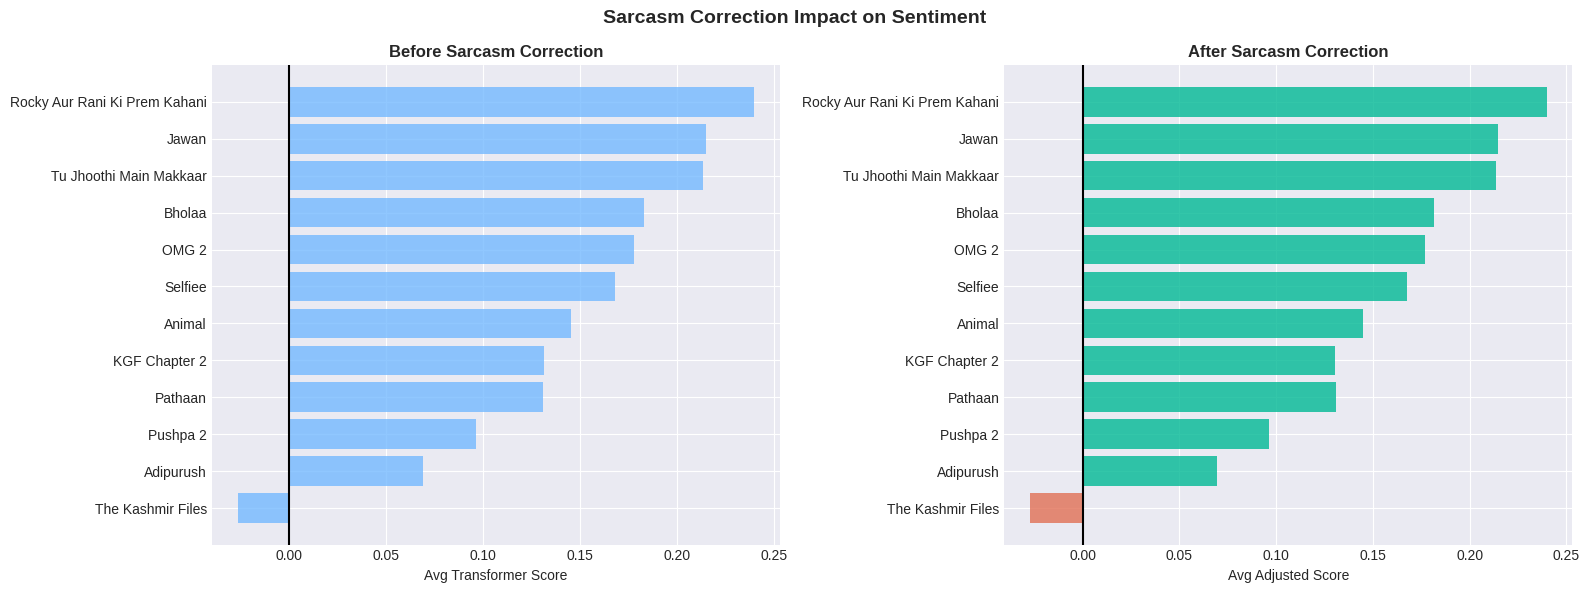

✅ Sarcasm-adjusted sentiment complete


In [13]:
# ── CELL 14: SARCASM-ADJUSTED SENTIMENT ──────────────────────────────────
# Core logic:
# If sarcasm detected AND comment was positive → flip to negative
# If sarcasm detected AND comment was neutral  → slight negative push (-0.1)
# If sarcasm detected AND comment was negative → keep as is (already negative)
# No sarcasm → keep original transformer score

def adjusted_sentiment_score(row):
    base_score = row['transformer_score']
    base_label = row['transformer_label']

    if row['is_sarcastic'] == 1:
        if base_label == 'positive':
            return -abs(base_score)   # flip positive → negative
        elif base_label == 'neutral':
            return -0.1               # slight negative push
        else:
            return base_score         # already negative — keep
    return base_score

def adjusted_sentiment_label(score):
    if score >  0.05: return 'positive'
    if score < -0.05: return 'negative'
    return 'neutral'

comments_df['adjusted_score'] = comments_df.apply(
    adjusted_sentiment_score, axis=1)
comments_df['adjusted_label'] = comments_df['adjusted_score'].apply(
    adjusted_sentiment_label)

print('📊 Sentiment Distribution — Before vs After Sarcasm Correction:')
print(f"\n{'Label':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print('─' * 44)
for label in ['positive', 'negative', 'neutral']:
    before = (comments_df['transformer_label'] == label).sum()
    after  = (comments_df['adjusted_label']    == label).sum()
    change = after - before
    sign   = '+' if change > 0 else ''
    print(f'{label:<12} {before:>10,} {after:>10,} {sign}{change:>9,}')

# Show sample corrections
print(f'\n📝 Sample sarcasm corrections (sentiment flipped):')
flipped = comments_df[
    (comments_df['is_sarcastic']==1) &
    (comments_df['transformer_label'] != comments_df['adjusted_label'])
][['text','transformer_label','adjusted_label']].head(5)

for _, row in flipped.iterrows():
    print(f'   Comment : {str(row["text"])[:70]}')
    print(f'   Before  : {row["transformer_label"]} → After: {row["adjusted_label"]}')
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sarcasm Correction Impact on Sentiment', fontsize=14, fontweight='bold')

before_avg = comments_df.groupby('movie')['transformer_score'].mean().sort_values()
after_avg  = comments_df.groupby('movie')['adjusted_score'].mean().reindex(before_avg.index)

axes[0].barh(before_avg.index, before_avg.values, color='#74B9FF', alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=1.5)
axes[0].set_title('Before Sarcasm Correction', fontweight='bold')
axes[0].set_xlabel('Avg Transformer Score')

axes[1].barh(after_avg.index, after_avg.values,
             color=['#00B894' if v > 0 else '#E17055' for v in after_avg.values],
             alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=1.5)
axes[1].set_title('After Sarcasm Correction', fontweight='bold')
axes[1].set_xlabel('Avg Adjusted Score')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}sarcasm_correction.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Sarcasm-adjusted sentiment complete')

In [14]:
# ── CELL 15: AGGREGATE ALL SCORES PER MOVIE ───────────────────────────────
# Collapse 46,000+ comment rows into 1 row per movie
# Separate aggregation for trailer vs music comments

# ── Trailer sentiment aggregate
trailer_agg = comments_df[comments_df['source']=='trailer'].groupby('movie').agg(
    trailer_vader_score      = ('vader_compound',    'mean'),
    trailer_sentiment_score  = ('adjusted_score',    'mean'),
    trailer_positive_ratio   = ('adjusted_label',    lambda x: (x=='positive').mean()),
    trailer_negative_ratio   = ('adjusted_label',    lambda x: (x=='negative').mean()),
    trailer_sarcasm_rate     = ('is_sarcastic',      'mean'),
    trailer_theatre_score    = ('theatre_excitement','mean'),
    trailer_ott_score        = ('ott_preference',    'mean'),
    trailer_controversy      = ('controversy_score', 'mean'),
    trailer_hype             = ('hype_score',        'mean'),
    trailer_comment_count    = ('text',              'count'),
).reset_index()

# ── Music sentiment aggregate (combines music_1 and music_2)
music_agg = comments_df[
    comments_df['source'].isin(['music_1','music_2'])
].groupby('movie').agg(
    music_vader_score        = ('vader_compound',    'mean'),
    music_sentiment_score    = ('adjusted_score',    'mean'),
    music_positive_ratio     = ('adjusted_label',    lambda x: (x=='positive').mean()),
    music_negative_ratio     = ('adjusted_label',    lambda x: (x=='negative').mean()),
    music_sarcasm_rate       = ('is_sarcastic',      'mean'),
    music_theatre_score      = ('theatre_excitement','mean'),
    music_ott_score          = ('ott_preference',    'mean'),
    music_controversy        = ('controversy_score', 'mean'),
    music_hype               = ('hype_score',        'mean'),
    music_comment_count      = ('text',              'count'),
).reset_index()

# ── Overall aggregate (all sources combined)
overall_agg = comments_df.groupby('movie').agg(
    vader_mean_compound      = ('vader_compound',        'mean'),
    vader_positive_ratio     = ('vader_label',           lambda x: (x=='positive').mean()),
    vader_negative_ratio     = ('vader_label',           lambda x: (x=='negative').mean()),
    vader_neutral_ratio      = ('vader_label',           lambda x: (x=='neutral').mean()),
    tb_mean_polarity         = ('tb_polarity',           'mean'),
    tb_mean_subjectivity     = ('tb_subjectivity',       'mean'),
    transformer_mean_score   = ('transformer_score',     'mean'),
    transformer_pos_ratio    = ('transformer_label',     lambda x: (x=='positive').mean()),
    transformer_neg_ratio    = ('transformer_label',     lambda x: (x=='negative').mean()),
    adjusted_mean_score      = ('adjusted_score',        'mean'),
    adjusted_pos_ratio       = ('adjusted_label',        lambda x: (x=='positive').mean()),
    adjusted_neg_ratio       = ('adjusted_label',        lambda x: (x=='negative').mean()),
    sarcasm_rate             = ('is_sarcastic',          'mean'),
    emoji_sarcasm_rate       = ('emoji_likely_sarcastic','mean'),
    pattern_sarcasm_rate     = ('pattern_sarcasm',       lambda x: (x>0).mean()),
    theatre_excitement_score = ('theatre_excitement',    'mean'),
    ott_preference_score     = ('ott_preference',        'mean'),
    controversy_intensity    = ('controversy_score',     'mean'),
    hype_density             = ('hype_score',            'mean'),
    total_comments           = ('text',                  'count'),
).reset_index()

# Theatre vs OTT excitement ratio
overall_agg['theatre_vs_ott_ratio'] = (
    overall_agg['theatre_excitement_score'] /
    overall_agg['ott_preference_score'].replace(0, 0.001)
).round(4)

# Merge all aggregates
sentiment_agg = overall_agg.copy()
sentiment_agg = sentiment_agg.merge(trailer_agg, on='movie', how='left')
sentiment_agg = sentiment_agg.merge(music_agg,   on='movie', how='left')

# Trailer vs Music sentiment gap (novel feature)
sentiment_agg['trailer_music_sentiment_gap'] = (
    sentiment_agg['trailer_sentiment_score'] -
    sentiment_agg['music_sentiment_score']
).round(4)

print('✅ Sentiment aggregated — trailer, music and overall separately')
print(f'   Shape: {sentiment_agg.shape}')

print(f'\n📊 Overall adjusted sentiment per movie (sorted best to worst):')
key_cols = [
    'movie','adjusted_mean_score','transformer_mean_score',
    'sarcasm_rate','theatre_excitement_score',
    'ott_preference_score','controversy_intensity'
]
print(sentiment_agg[key_cols].sort_values(
    'adjusted_mean_score', ascending=False
).to_string(index=False))

print(f'\n📊 Trailer vs Music sentiment gap:')
gap_cols = ['movie','trailer_sentiment_score','music_sentiment_score','trailer_music_sentiment_gap']
print(sentiment_agg[gap_cols].sort_values(
    'trailer_music_sentiment_gap', ascending=False
).to_string(index=False))

✅ Sentiment aggregated — trailer, music and overall separately
   Shape: (12, 43)

📊 Overall adjusted sentiment per movie (sorted best to worst):
                        movie  adjusted_mean_score  transformer_mean_score  sarcasm_rate  theatre_excitement_score  ott_preference_score  controversy_intensity
Rocky Aur Rani Ki Prem Kahani             0.239778                0.239836      0.002020                  0.024531              0.010390               0.056277
                        Jawan             0.214707                0.215274      0.004137                  0.059102              0.007683               0.040780
      Tu Jhoothi Main Makkaar             0.213399                0.213458      0.000588                  0.015281              0.005583               0.017044
                       Bholaa             0.181556                0.182868      0.003833                  0.044395              0.009901               0.048547
                        OMG 2             0.176797    

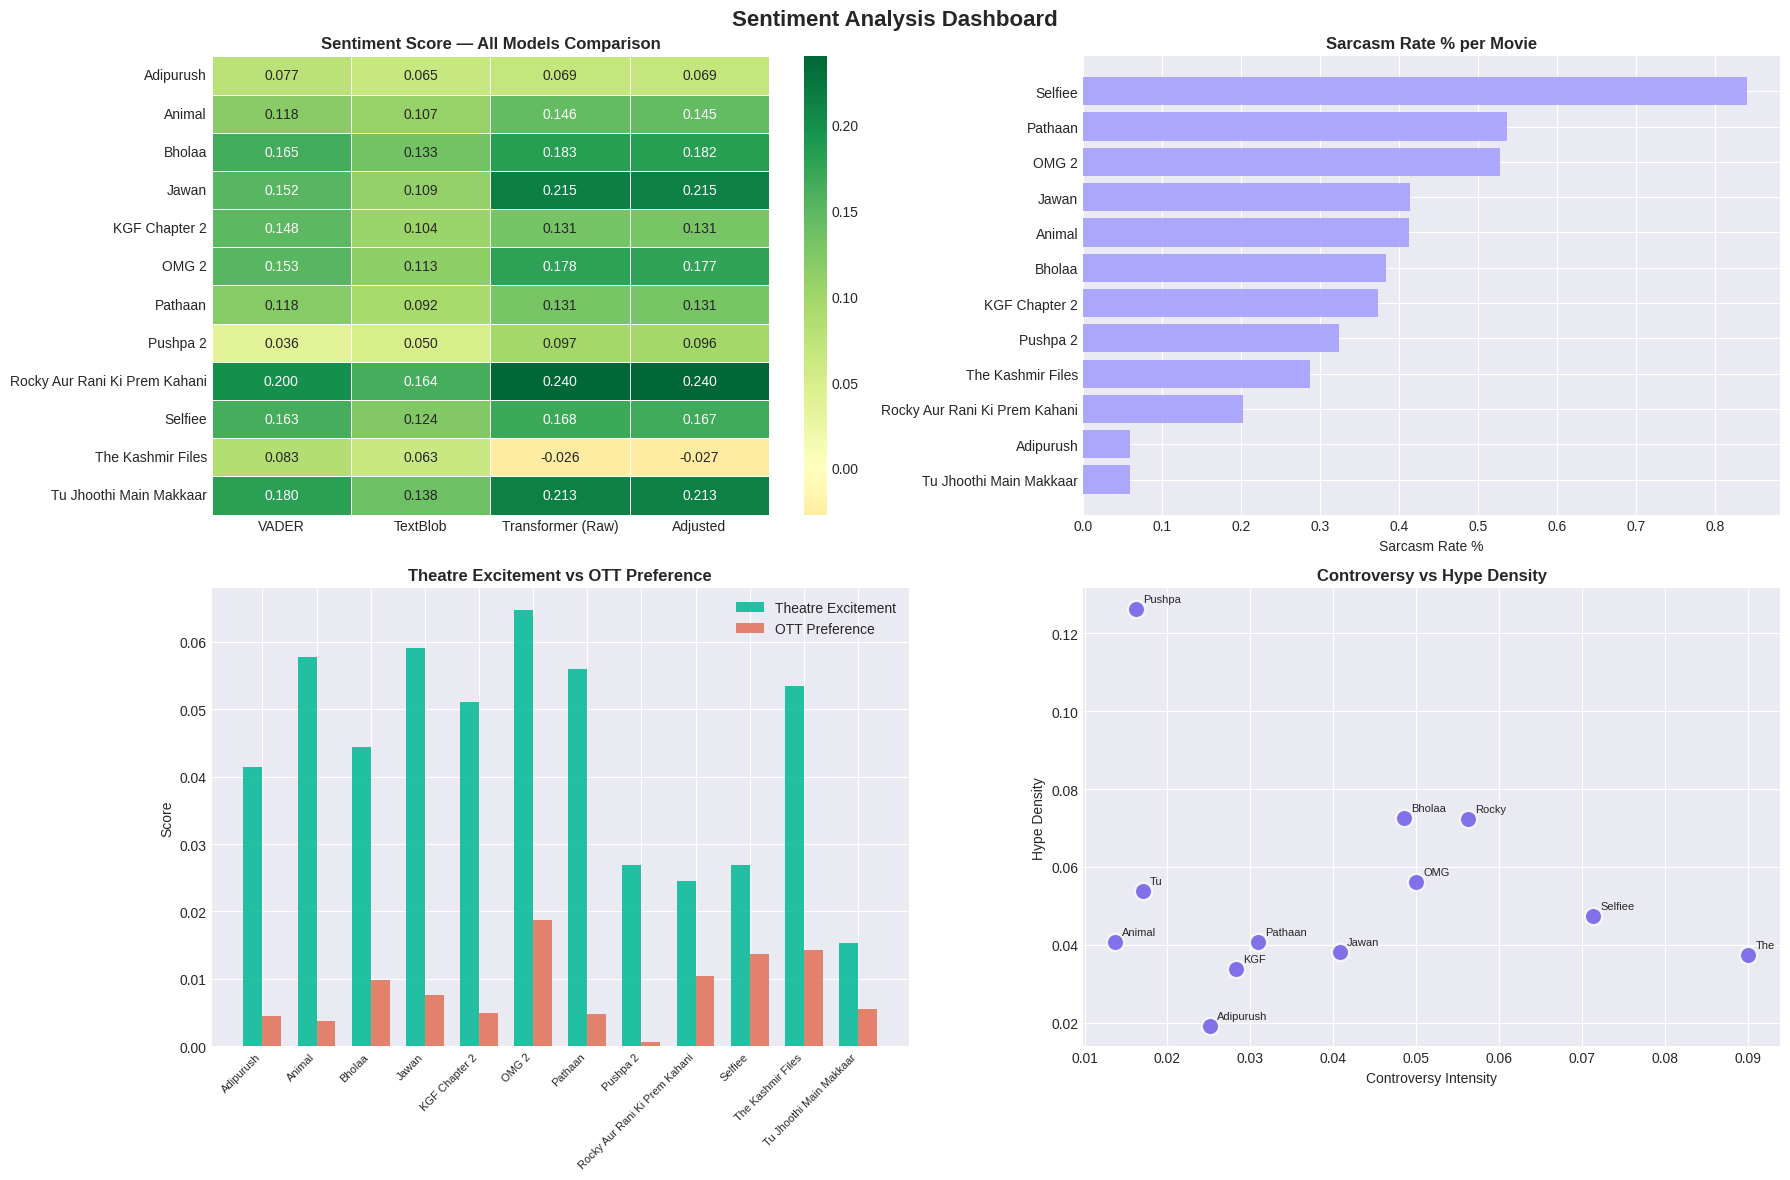

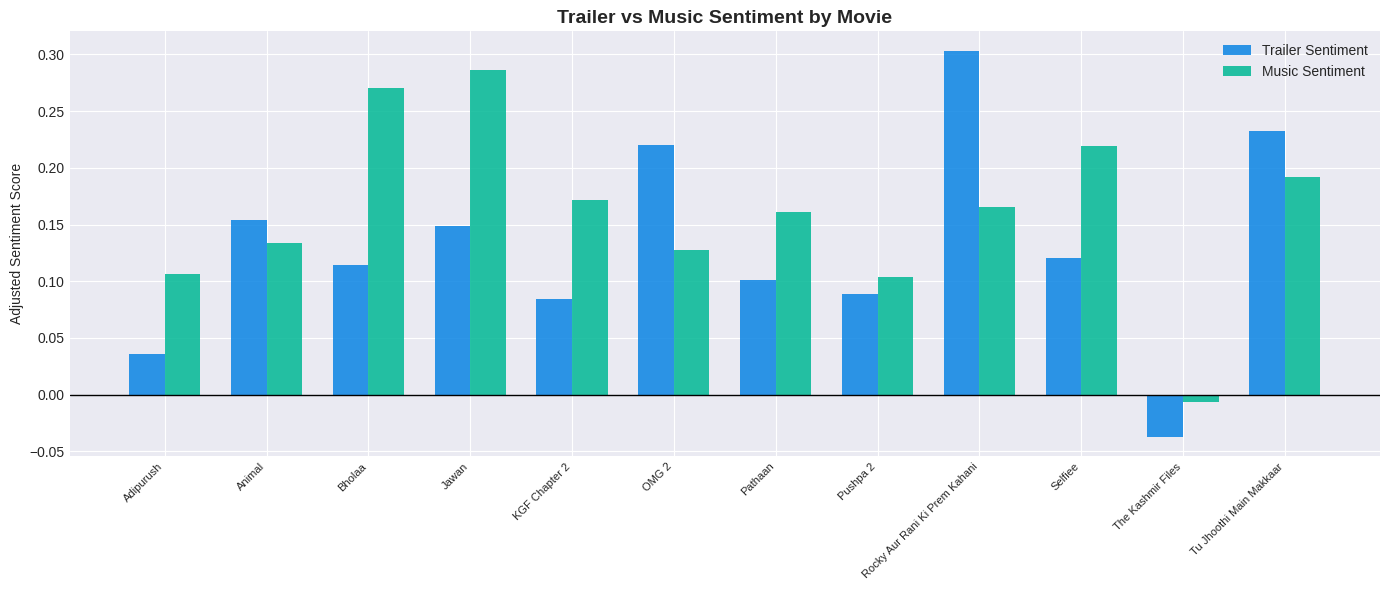

In [15]:
# ── CELL 16: VISUALIZATIONS ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Sentiment heatmap — all 3 models
ax1 = axes[0, 0]
heat_data = sentiment_agg.set_index('movie')[[
    'vader_mean_compound',
    'tb_mean_polarity',
    'transformer_mean_score',
    'adjusted_mean_score'
]].rename(columns={
    'vader_mean_compound'   : 'VADER',
    'tb_mean_polarity'      : 'TextBlob',
    'transformer_mean_score': 'Transformer (Raw)',
    'adjusted_mean_score'   : 'Adjusted'
})
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax1, center=0, linewidths=0.5)
ax1.set_title('Sentiment Score — All Models Comparison', fontweight='bold')
ax1.set_ylabel('')

# 2. Sarcasm rate
ax2 = axes[0, 1]
sorted_s = sentiment_agg.sort_values('sarcasm_rate', ascending=True)
ax2.barh(sorted_s['movie'], sorted_s['sarcasm_rate'] * 100,
         color='#A29BFE', alpha=0.85)
ax2.set_title('Sarcasm Rate % per Movie', fontweight='bold')
ax2.set_xlabel('Sarcasm Rate %')

# 3. Theatre vs OTT grouped bar
ax3 = axes[1, 0]
x   = np.arange(len(sentiment_agg))
w   = 0.35
ax3.bar(x - w/2, sentiment_agg['theatre_excitement_score'],
        w, label='Theatre Excitement', color='#00B894', alpha=0.85)
ax3.bar(x + w/2, sentiment_agg['ott_preference_score'],
        w, label='OTT Preference',     color='#E17055', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(sentiment_agg['movie'], rotation=45, ha='right', fontsize=8)
ax3.set_title('Theatre Excitement vs OTT Preference', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend()

# 4. Controversy vs Hype scatter
ax4 = axes[1, 1]
ax4.scatter(
    sentiment_agg['controversy_intensity'],
    sentiment_agg['hype_density'],
    s=150, alpha=0.85,
    color='#6C5CE7', edgecolors='white', linewidth=1.5
)
for _, row in sentiment_agg.iterrows():
    ax4.annotate(
        row['movie'].split()[0],
        (row['controversy_intensity'], row['hype_density']),
        textcoords='offset points', xytext=(5, 5), fontsize=8
    )
ax4.set_title('Controversy vs Hype Density', fontweight='bold')
ax4.set_xlabel('Controversy Intensity')
ax4.set_ylabel('Hype Density')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Trailer vs Music sentiment comparison
fig2, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sentiment_agg))
w = 0.35
ax.bar(x - w/2, sentiment_agg['trailer_sentiment_score'],
       w, label='Trailer Sentiment', color='#0984E3', alpha=0.85)
ax.bar(x + w/2, sentiment_agg['music_sentiment_score'],
       w, label='Music Sentiment',   color='#00B894', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sentiment_agg['movie'], rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Trailer vs Music Sentiment by Movie', fontsize=14, fontweight='bold')
ax.set_ylabel('Adjusted Sentiment Score')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}trailer_vs_music_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── CELL 17: SAVE ALL DATA ────────────────────────────────────────────────

# Save comment-level data with all sentiment + sarcasm scores
comments_df.to_csv(f'{SAVE_PATH}comments_sentiment.csv', index=False)
print(f'✅ Comment-level data saved   : {comments_df.shape}')

# Save movie-level aggregated sentiment
sentiment_agg.to_csv(f'{SAVE_PATH}sentiment_scores.csv', index=False)
print(f'✅ Movie sentiment scores saved: {sentiment_agg.shape}')

print(f'\n📊 All columns in comments_sentiment.csv:')
for col in comments_df.columns:
    print(f'   • {col}')

print(f'\n📊 All columns in sentiment_scores.csv:')
for col in sentiment_agg.columns:
    print(f'   • {col}')

print(f'\n✅ Notebook 3 complete — proceed to Notebook 4: Feature Engineering')

✅ Comment-level data saved   : (39353, 31)
✅ Movie sentiment scores saved: (12, 43)

📊 All columns in comments_sentiment.csv:
   • text
   • likes
   • reply_count
   • time
   • source_type
   • movie
   • source
   • text_clean
   • text_sentiment
   • vader_compound
   • vader_positive
   • vader_negative
   • vader_neutral
   • vader_label
   • tb_polarity
   • tb_subjectivity
   • tb_label
   • transformer_label
   • transformer_score
   • theatre_excitement
   • ott_preference
   • controversy_score
   • hype_score
   • emoji_sarcasm_count
   • emoji_genuine_count
   • emoji_likely_sarcastic
   • pattern_sarcasm
   • sarcasm_transformer
   • is_sarcastic
   • adjusted_score
   • adjusted_label

📊 All columns in sentiment_scores.csv:
   • movie
   • vader_mean_compound
   • vader_positive_ratio
   • vader_negative_ratio
   • vader_neutral_ratio
   • tb_mean_polarity
   • tb_mean_subjectivity
   • transformer_mean_score
   • transformer_pos_ratio
   • transformer_neg_ratio
   • adj